# Seção 1 – Comparativo com modelos clássicos de séries temporais
**Pergunta:** a escolha de Ridge + LightGBM se sustenta frente aos modelos clássicos de previsão (ETS, SARIMAX, Prophet)?

**Protocolo idêntico ao do notebook 02:** mesmos dias de teste (4 janelas de 14 dias do walk-forward + holdout de 30 dias de junho),
previsão com 7 dias de antecedência (para prever o dia D usa só dados até D−7), mesmas métricas e alvo em log.

| Modelo | Ideia | Como foi configurado |
|---|---|---|
| **Naive sazonal** | Mesmo dia da semana, semana anterior | Sem parâmetros |
| **ETS (auto)** | Suavização exponencial com nível, tendência amortecida e sazonalidade semanal | Parâmetros otimizados pela biblioteca (erro de 1 passo) |
| **ETS (ajustado)** | Idem, sem tendência, com suavização escolhida para o erro de **7 passos** | α e γ escolhidos em grade nas 4 últimas semanas do treino de cada janela |
| **SARIMAX** | ARMA com sazonalidade semanal | Ordem escolhida por AIC só com dados anteriores à 1ª janela de teste |
| **SARIMAX (eventos)** | Idem, com variáveis de calendário/eventos como regressores | Mesma ordem; só entram regressores de evento com **pelo menos 5 dias ativos no treino** (regra criada depois de ver que um evento com 1 dia de evidência gerava coeficiente absurdo) |
| **Prophet** | Tendência + sazonalidade semanal + efeitos de feriados/eventos | Sazonalidade anual desligada (só 8 meses); feriados e eventos com janelas |
| **Ridge, LightGBM, Média** | Modelos do notebook 02 (cenário A) | Mesmos parâmetros |
| **XGBoost** | Outro modelo de boosting de árvores, bastante usado em projeção de vendas | Mesmas variáveis; árvores rasas (profundidade 3), 300 árvores, taxa 0,03 |

As previsões dos modelos clássicos levam ~8 min para serem geradas (reajuste a cada dia de teste); por isso ficam em cache em `reports/benchmark_*.csv`.

In [1]:
import json, sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from src.data import carregar, serie_diaria
from src import benchmarks as B
from src.viz import aplicar_estilo, salvar, milhoes, AZUL, LARANJA, AQUA, CINZA
aplicar_estilo()
d = serie_diaria(carregar())
RAIZ = Path('..')
ALVOS = {'receita_aprovada': 'Receita aprovada', 'nr_pedidos': 'Nº de pedidos'}
R, TAB, PRED = {}, {}, {}
for alvo in ALVOS:
    cache = RAIZ / 'reports' / f'benchmark_{alvo}.csv'
    if cache.exists():
        p = pd.read_csv(cache, index_col=0, parse_dates=True)
        yy = p.pop('real')
        meta = json.load(open(RAIZ / 'reports' / 'benchmark_meta.json'))[alvo]
        jan, n = [tuple(j) for j in meta['janelas']], meta['n']
    else:  # sem cache: recalcula (lento)
        p, yy, jan, n, _ = B.rodar(d[alvo])
    PRED[alvo] = (p, yy, jan, n)
    TAB[alvo] = B.resumir(p, yy, jan, n)

## Resultados – receita aprovada

In [2]:
TAB['receita_aprovada'].round(1).sort_values('WAPE walk-forward (%)')

,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Ridge,23.6,29.6,31.8,467938.4,7.0
SARIMAX (eventos),24.0,28.4,30.9,448821.5,4.5
SARIMAX,24.1,32.2,36.4,509426.0,11.7
Média Ridge+LGBM,24.1,29.9,32.8,473267.3,8.6
XGBoost,26.3,25.9,26.0,409906.5,-2.7
LightGBM,27.5,30.4,34.1,481271.2,10.2
ETS (ajustado),27.8,36.1,38.9,570657.2,6.0
Prophet,33.9,31.2,35.0,493367.1,12.3
ETS (auto),34.2,35.1,36.3,555403.6,-2.3


## Resultados – nº de pedidos

In [3]:
TAB['nr_pedidos'].round(1).sort_values('WAPE walk-forward (%)')

,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Média Ridge+LGBM,27.0,27.4,32.7,4672.8,11.6
Ridge,27.2,27.3,32.4,4665.1,11.6
SARIMAX (eventos),27.4,25.9,28.4,4420.5,-2.6
LightGBM,27.9,28.9,34.3,4924.0,11.6
XGBoost,28.1,24.1,26.8,4113.6,-0.2
SARIMAX,28.5,26.2,30.7,4467.6,8.3
ETS (ajustado),29.5,37.7,42.5,6435.4,7.5
Prophet,36.1,30.4,35.7,5179.3,11.3
ETS (auto),38.3,29.7,31.4,5060.2,-9.0


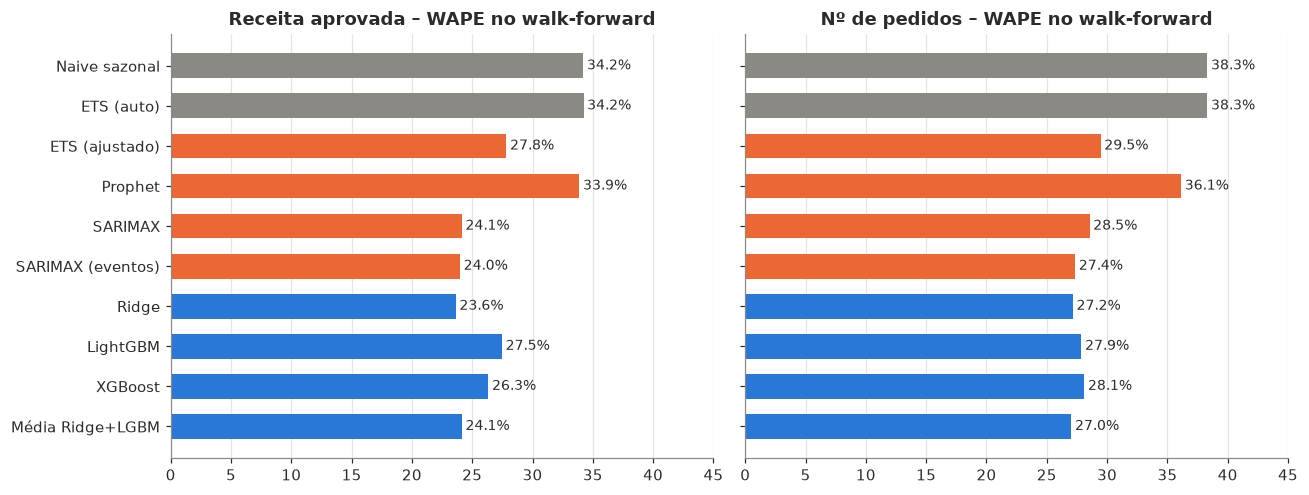

In [4]:
ordem = ['Naive sazonal', 'ETS (auto)', 'ETS (ajustado)', 'Prophet', 'SARIMAX', 'SARIMAX (eventos)', 'Ridge', 'LightGBM', 'XGBoost', 'Média Ridge+LGBM']
cor = {m: (CINZA if m in ('Naive sazonal', 'ETS (auto)') else AZUL if m in ('Ridge', 'LightGBM', 'XGBoost', 'Média Ridge+LGBM') else LARANJA) for m in ordem}
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, (alvo, nome) in zip(axs, ALVOS.items()):
    t = TAB[alvo].loc[ordem, 'WAPE walk-forward (%)']
    ax.barh(t.index[::-1], t.values[::-1], color=[cor[m] for m in t.index[::-1]], height=.62)
    for y_, v in enumerate(t.values[::-1]): ax.text(v + .3, y_, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_title(f'{nome} – WAPE no walk-forward'); ax.grid(axis='y', visible=False); ax.set_xlim(0, 45)
plt.tight_layout(); salvar(fig, '11_comparativo_modelos'); plt.show()

## Por que o "ETS (auto)" é idêntico ao baseline?
Não é erro de código. A biblioteca ajusta os parâmetros minimizando o erro de **1 passo à frente**; como a série é muito persistente
(autocorrelação de 0,77 em 1 dia), escolhe `smoothing_level = 1` (o nível é sempre o último valor observado) e sazonalidade fixa. Com período
sazonal de 7 e previsão a 7 dias, isso reduz-se matematicamente a "valor de 7 dias atrás" — exatamente o baseline. Para o horizonte que nos
interessa, é preciso escolher a suavização pelo erro de 7 passos, que é o que o "ETS (ajustado)" faz.

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
yl = np.log1p(d.nr_pedidos); o = 149
r = ExponentialSmoothing(yl.iloc[:o + 1], trend='add', damped_trend=True, seasonal='add', seasonal_periods=7).fit()
print('smoothing_level =', round(float(r.params['smoothing_level']), 3), '| smoothing_seasonal =', round(float(r.params['smoothing_seasonal']), 3))
print('previsão ETS(auto) a 7 dias:', round(float(np.expm1(r.forecast(7).iloc[-1]))), '| baseline (valor de 7 dias antes):', int(d.nr_pedidos.iloc[o]))

smoothing_level = 1.0 | smoothing_seasonal = 0.0
previsão ETS(auto) a 7 dias: 13668 | baseline (valor de 7 dias antes): 13668


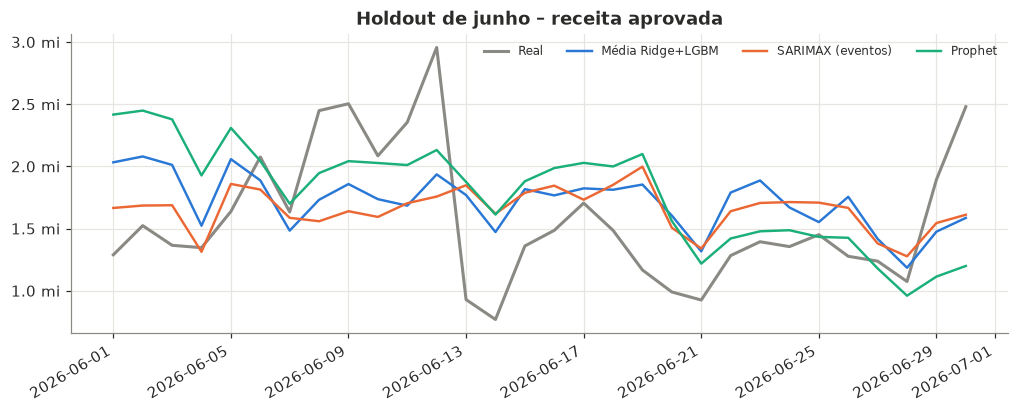

In [6]:
alvo = 'receita_aprovada'; p, yy, jan, n = PRED[alvo]
ho = p.index[n - jan[0][0]:]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ho, yy.loc[ho], color=CINZA, label='Real')
for m, c in [('Média Ridge+LGBM', AZUL), ('SARIMAX (eventos)', LARANJA), ('Prophet', AQUA)]:
    ax.plot(ho, p.loc[ho, m], color=c, lw=1.6, label=m)
ax.yaxis.set_major_formatter(FuncFormatter(milhoes)); ax.set_title('Holdout de junho – receita aprovada'); ax.legend(ncol=4, fontsize=8)
fig.autofmt_xdate(); salvar(fig, '12_comparativo_holdout'); plt.show()

## Conclusões
1. **Topo empatado.** No walk-forward (4 janelas, 56 dias), receita: Ridge 23,6%, SARIMAX com eventos 24,0%, SARIMAX 24,1% e média Ridge+LightGBM 24,1%; pedidos: média 27,0%, Ridge 27,2% e SARIMAX com eventos 27,4%.
   As diferenças são de ≤ 0,5 ponto de WAPE: **não dá para dizer que um seja melhor que o outro**.
2. **XGBoost: resultado inconsistente entre validações.** É dos piores no walk-forward entre os modelos de ML (26,3% na receita e 28,1% em pedidos), mas o **melhor no holdout** (25,9% e 24,1%, viés próximo de zero).
   O holdout é um único mês de 30 dias, atípico (Dia dos Namorados, jogos da Copa, desconto de 55% no fim); o walk-forward cobre 4 janelas em momentos diferentes. Com amostra tão curta, esse tipo de inversão é comum, e **escolher o modelo pelo holdout seria
   sobreajuste**. XGBoost e LightGBM, que são da mesma família (boosting de árvores), não superam o Ridge no walk-forward.
3. **ETS (auto) = baseline**, por construção (explicado acima). O **ETS (ajustado)** melhora no walk-forward (27,8% na receita), mas **piora no holdout** (36,1% contra 35,1% do baseline): instável.
4. **Prophet** fica perto do baseline (33,9% e 36,1% no walk-forward) e com viés positivo de ~12% na receita no holdout. Provável causa: usa sazonalidade semanal fixa e tendência, sem o nível recente das últimas semanas; com 8 meses, a Black Friday
   também distorce a tendência e uma sazonalidade anual não é estimável.
5. **Ingredientes do ganho:** todos que ficam à frente do baseline combinam o nível/padrão recente (lags, parte autorregressiva) com o calendário de eventos (incluindo a Beauty Week). Nenhum modelo passa de ~24% de WAPE na receita e ~27% em pedidos no walk-forward:
   o limite vem da informação (campanhas fora do calendário), não do algoritmo.
6. **Sobre a escolha de Ridge e LightGBM:** o Ridge sozinho está entre os melhores; o LightGBM **não** trouxe ganho sobre ele e a média dos dois não supera o Ridge na receita. A justificativa honesta para manter a família Ridge + árvores é simplicidade, interpretabilidade
   e facilidade de estender com variáveis novas (calendário comercial, mídia), não superioridade medida.
7. **Limites e transparência:** (a) a regra "regressor de evento só entra no SARIMAX com ≥ 5 dias ativos no treino" foi criada **depois** de uma primeira versão apresentar um coeficiente absurdo (evento com 1 dia de evidência → erro de 116% em uma janela); (b) a ordem do SARIMAX foi escolhida por AIC com poucas combinações;
   (c) os clássicos são reajustados a cada dia de teste, enquanto o ML é treinado uma vez por janela, o que favorece os clássicos; (d) não testamos redes neurais nem modelos globais por categoria, pelo volume de dados; (e) o ajuste de hiperparâmetros das árvores está no notebook 02.

In [7]:
R['tabelas'] = {a: TAB[a].round(1).to_dict('index') for a in TAB}
R['ordem_sarimax'] = json.load(open(RAIZ / 'reports' / 'benchmark_meta.json'))
json.dump(R, open(RAIZ / 'reports' / 'resultados_benchmark.json', 'w'), ensure_ascii=False, indent=2, default=str)